# 돌봄부담 진단 모델 — 학습 과정

`models/v1.1.0`(14문항)이 어떻게 만들어졌는지를 **DB에서 다시 계산해** 보여준다.
저장된 값을 옮겨 적지 않고 재산출한 뒤 산출물과 나란히 놓아 **일치 여부까지 확인**한다.

| 항목 | 값 |
|---|---|
| 대상 모델 | `v1.1.0` · 문항집합 `qs-v1.1.0` · 14문항 |
| 알고리즘 | 다항 로지스틱 회귀 |
| 데이터 | `ABC8pioneer3` · `v_cb_tree_v1` (2024 실태조사 3,000가구) |
| 분할 | train 2,398 / test 602 · train 내부 5-fold (DB 고정) |
| 문서 | `docs/모델-학습-방법.md` |

## 이 노트북이 지키는 것

- **파이프라인을 복제하지 않는다.** `ml/train.py`의 함수를 그대로 불러 쓴다. 코드가 갈라지면
  노트북 숫자와 실제 모델이 달라지기 때문이다.
- **test 602건을 쓰지 않는다.** 모든 수치는 train 2,398건의 교차검증 값이다.
- **분할을 새로 만들지 않는다.** DB의 `split`·`cv_fold`를 그대로 읽는다(헌법 원칙 IV).

## 척도 방향 — 먼저 읽을 것

`care_burden`은 **1이 최고부담, 5가 부담 없음**이다. 숫자가 작을수록 부담이 크다.
"고부담군"은 1~2단계를 뜻한다.

## 1. 준비

접속 정보는 프로젝트 루트의 `.env`에서 읽는다. 노트북에 자격증명을 적지 않는다.

```bash
uv run --with pandas,matplotlib,scikit-learn,pymysql jupyter lab
```

In [1]:
import os, sys, json, time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'ml'))          # ml/train.py 를 그대로 쓴다
sys.path.append(str(ROOT / 'ml' / '.pylibs'))   # 없는 것만 채운다. 실행 환경 패키지가 우선

def load_env(fn='.env'):
    for d in (ROOT, *ROOT.parents):
        p = d / fn
        if p.is_file():
            for line in p.read_text(encoding='utf-8').splitlines():
                line = line.strip()
                if line and not line.startswith('#') and '=' in line:
                    k, v = line.split('=', 1)
                    os.environ.setdefault(k.strip(), v.strip().strip('\'"'))
            return p
print('.env :', load_env() or '못 찾음')

import numpy as np
import sklearn          # train.py 보다 먼저 올려 실행 환경 버전을 고정한다
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 한글 폰트
_inst = {f.name for f in font_manager.fontManager.ttflist}
for c in ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'Malgun Gothic']:
    if c in _inst:
        mpl.rcParams['font.family'] = c
        break
mpl.rcParams['axes.unicode_minus'] = False

# 팔레트 — 부담 5구간은 단일 색상 순차 램프(진할수록 고부담)
BURDEN = {1:'#801e1e', 2:'#a92e2d', 3:'#d04442', 4:'#dd7170', 5:'#e99b9a'}
NAME   = {1:'최고부담군', 2:'고부담군', 3:'중간부담군', 4:'저부담군', 5:'부담 없음'}
CAT1, CAT2, CAT3 = '#2a78d6', '#eb6834', '#8a8a86'
SURFACE, INK1, INK2, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#e6e5e1', '#c8c7c2'
mpl.rcParams.update({'figure.facecolor':SURFACE, 'axes.facecolor':SURFACE, 'savefig.facecolor':SURFACE,
                     'figure.dpi':110, 'font.size':10, 'axes.titlesize':12, 'axes.titleweight':'bold',
                     'axes.titlecolor':INK1, 'axes.labelcolor':INK2, 'text.color':INK1,
                     'xtick.color':INK2, 'ytick.color':INK2})

def style(ax, grid='y'):
    ax.set_axisbelow(True)
    if grid: ax.grid(axis=grid, color=GRID, lw=0.8, zorder=0)
    for s in ('top','right'): ax.spines[s].set_visible(False)
    for s in ('left','bottom'): ax.spines[s].set_color(AXIS); ax.spines[s].set_linewidth(0.8)
    ax.tick_params(length=0)
    return ax

import train as T          # __main__ 가드가 있어 임포트만으로는 아무것도 실행되지 않는다
import db as dbmod
print('파이프라인 로드 완료 · 시드', T.SEED)
print('정지 조건 : F1손실 <=', T.MAX_F1_LOSS, '· 재현율손실 <=', T.MAX_REC_LOSS,
      '· 재현율 >=', T.MIN_REC_ABS, f'(마진 F1 {T.F1_MARGIN} / 재현율 {T.REC_MARGIN})')

.env : /Users/pioneer3/project2608/.env


파이프라인 로드 완료 · 시드 20260901
정지 조건 : F1손실 <= 0.03 · 재현율손실 <= 0.05 · 재현율 >= 0.7 (마진 F1 0.01 / 재현율 0.03)


## 2. 데이터 적재와 분할 검증

`ml/db.py`는 적재할 때마다 다섯 가지를 확인하고 하나라도 어긋나면 즉시 실패한다.
아래 셀이 오류 없이 끝나면 그 검증을 전부 통과한 것이다.

| 검사 | 기대값 |
|---|---|
| train 건수 | 2,398 |
| test 건수 | 602 |
| 설명변수 수 | 38 |
| cv_fold 배정 | 1~5 |
| 배제 6변수 부재 | Data Leakage 없음 (FR-004b) |

In [2]:
t0 = time.time()
d = dbmod.load_dataset(T.MISSING)
X, y, folds, feats = d['X'], d['y'], d['folds'], d['features']

print(f'적재 완료 ({time.time()-t0:.1f}s)')
print(f'  train {len(y):,}건 · test {len(d["ytest"]):,}건 · 설명변수 {len(feats)}개')
print(f'  결측 센티널 : {T.MISSING}  (NULL 을 채우지 않고 별도 범주로 둔다)')
print()
fold_n = pd.Series(folds).value_counts().sort_index()
print('cv_fold 배정 :', ' · '.join(f'fold{k} {v}' for k, v in fold_n.items()))
print('test 의 cv_fold : NULL (교차검증에 참여하지 않는다)')
print()
BANNED = ['caregiver_life_satisfaction','care_difficulty_top1','needed_care_service_type',
          'work_care_gap_hours','work_care_gap_exp','integrated_care_awareness']
print('배제 6변수가 입력에 없는가 :', all(b not in feats for b in BANNED))

적재 완료 (0.1s)
  train 2,398건 · test 602건 · 설명변수 38개
  결측 센티널 : -1  (NULL 을 채우지 않고 별도 범주로 둔다)

cv_fold 배정 : fold1 483 · fold2 481 · fold3 478 · fold4 478 · fold5 478
test 의 cv_fold : NULL (교차검증에 참여하지 않는다)

배제 6변수가 입력에 없는가 : True


## 3. target 분포 — 층화가 유지됐는가

두 가지를 본다.

- **불균형의 크기** — 5단계(부담 없음)가 몇 건인지가 macro F1(SC-004)의 난이도를 좌우한다.
- **층화 성립 여부** — train과 test의 구간 비율이 어긋나면 최종 평가가 왜곡된다.

건수와 비율은 서로 다른 질문이므로 축을 나눈 두 차트로 본다.

,구간,train,test,train %,test %,차이 %p
1,최고부담군,371,93,15.5,15.4,-0.02
2,고부담군,932,233,38.9,38.7,-0.16
3,중간부담군,732,184,30.5,30.6,0.04
4,저부담군,302,76,12.6,12.6,0.03
5,부담 없음,61,16,2.5,2.7,0.11


findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


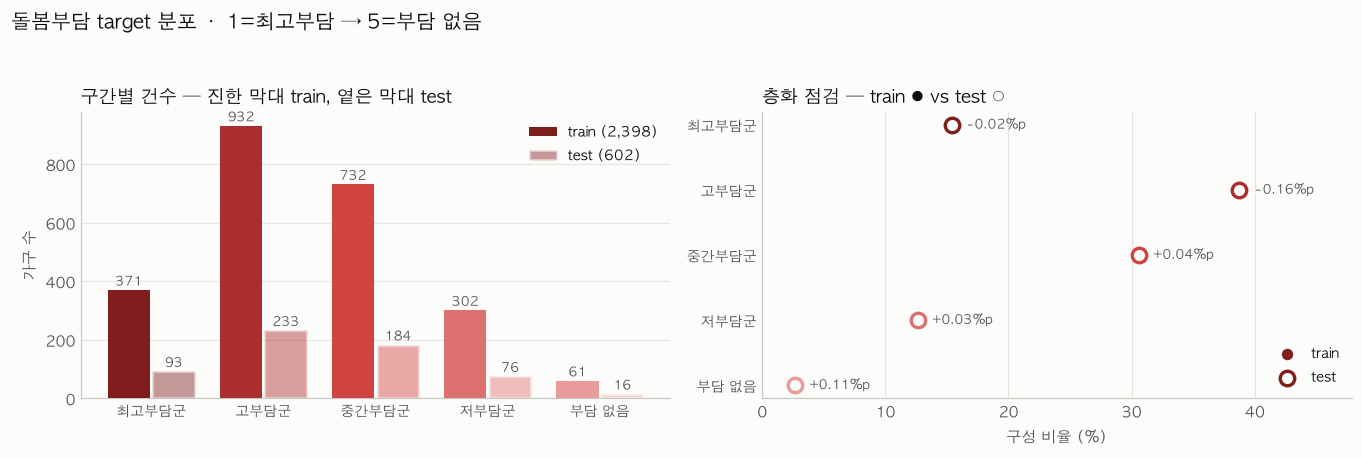

최대 층화 오차 : 0.16%p
고부담군(1~2) 비율 : train 54.3% · test 54.2%
5단계(부담 없음) train 표본 : 61건 — macro F1 의 병목


In [3]:
ytr = pd.Series(y); yte = pd.Series(d['ytest'])
ct = pd.DataFrame({'train': ytr.value_counts(), 'test': yte.value_counts()}).reindex([1,2,3,4,5]).fillna(0).astype(int)
pct = ct.div(ct.sum(axis=0), axis=1) * 100
tbl = ct.copy()
tbl.insert(0, '구간', [NAME[i] for i in tbl.index])
tbl['train %'] = pct['train'].round(1); tbl['test %'] = pct['test'].round(1)
tbl['차이 %p'] = (pct['test'] - pct['train']).round(2)
display(tbl)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))
x = np.arange(5); cols = [BURDEN[i] for i in [1,2,3,4,5]]; names = [NAME[i] for i in [1,2,3,4,5]]

ax = style(axes[0])
b1 = ax.bar(x-0.2, ct['train'], 0.38, color=cols, zorder=3)
b2 = ax.bar(x+0.2, ct['test'],  0.38, color=cols, alpha=0.45, zorder=3, edgecolor=SURFACE, lw=2)
for rs in (b1, b2):
    for r in rs:
        ax.annotate(f'{int(r.get_height()):,}', (r.get_x()+r.get_width()/2, r.get_height()),
                    ha='center', va='bottom', fontsize=8.5, color=INK2)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9); ax.set_ylabel('가구 수')
ax.set_title('구간별 건수 — 진한 막대 train, 옅은 막대 test', loc='left')
ax.legend([b1, b2], [f'train ({len(y):,})', f'test ({len(d["ytest"]):,})'], frameon=False, fontsize=9)

ax = style(axes[1], grid=None)
for i, lv in enumerate([1,2,3,4,5]):
    ax.plot([pct.loc[lv,'train'], pct.loc[lv,'test']], [i, i], color=GRID, lw=3, solid_capstyle='round', zorder=2)
    ax.scatter(pct.loc[lv,'train'], i, s=90, color=BURDEN[lv], zorder=4, edgecolor=SURFACE, lw=2,
               label='train' if i==0 else None)
    ax.scatter(pct.loc[lv,'test'], i, s=90, facecolor=SURFACE, zorder=4, edgecolor=BURDEN[lv], lw=2.2,
               label='test' if i==0 else None)
    ax.annotate(f'{pct.loc[lv,"test"]-pct.loc[lv,"train"]:+.2f}%p',
                (max(pct.loc[lv])+1.2, i), va='center', fontsize=8.5, color=INK2)
ax.set_yticks(range(5)); ax.set_yticklabels(names, fontsize=9); ax.invert_yaxis()
ax.set_xlim(0, pct.values.max()+9); ax.set_xlabel('구성 비율 (%)')
ax.grid(axis='x', color=GRID, lw=0.8)
ax.set_title('층화 점검 — train ● vs test ○', loc='left')
ax.legend(frameon=False, loc='lower right', fontsize=9)
fig.suptitle('돌봄부담 target 분포  ·  1=최고부담 → 5=부담 없음', x=0.005, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0,0,1,0.94]); plt.show()

print(f'최대 층화 오차 : {(pct["test"]-pct["train"]).abs().max():.2f}%p')
print(f'고부담군(1~2) 비율 : train {pct.loc[[1,2],"train"].sum():.1f}% · test {pct.loc[[1,2],"test"].sum():.1f}%')
print(f'5단계(부담 없음) train 표본 : {ct.loc[5,"train"]}건 — macro F1 의 병목')

## 4. 어떤 알고리즘을 쓸 것인가 — 계열 3종 비교

38개 설명변수 전체를 넣고 **같은 폴드·같은 지표**로 세 계열을 붙인다.

| 계열 | 성격 |
|---|---|
| `logit` 다항 로지스틱 회귀 | 선형. 원-핫 인코딩 후 학습 |
| `rf` 랜덤 포레스트 | 트리 수백 개를 독립적으로 만들어 다수결 |
| `et` 엑스트라 트리 | 랜덤 포레스트의 변형. 분할 지점을 더 무작위로 |

**채택 규칙**: 고부담 재현율 하한(0.70 + 마진 0.03)을 만족하는 계열 중 macro F1 이 가장 높은 것.

각 계열마다 **결정 가중치**도 함께 튜닝한다. 1·2단계 확률에 곱하는 값으로, 크면 고부담 판정이
늘어 재현율이 오르고 F1은 내려간다. 사람이 정하지 않고 규칙이 고른다.

,macro F1,고부담 재현율,결정 가중치,F1(가중치 없이),재현율(가중치 없이),초
계열,,,,,,
logit,0.3184,0.7475,1.15,0.3153,0.7122,0.6216
rf,0.2894,0.7552,1.00,0.2879,0.7552,1.4824
et,0.2668,0.7544,1.00,0.2660,0.7543,1.4143


산출물에 저장된 값과 대조:
  logit  저장 0.3180 / 재계산 0.3184  ★불일치
  rf     저장 0.2894 / 재계산 0.2894  일치
  et     저장 0.2668 / 재계산 0.2668  일치


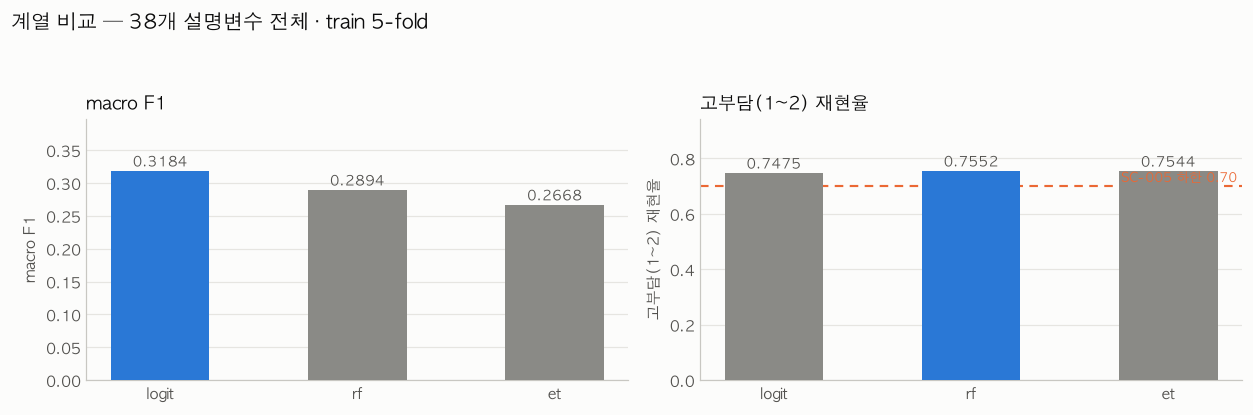

채택 계열 : logit
트리 계열이 선형 모델에 졌다. 2,398건에서 트리가 규칙을 잘게 쪼개며 과적합한 결과로 보인다.


In [4]:
rows = []
for fam in ['logit', 'rf', 'et']:
    t0 = time.time()
    raw = T.cv_scores(X, y, folds, feats, family=fam)
    w, tuned = T.tune_decision_weights(raw['oof_proba'], y)
    rows.append({'계열': fam, 'macro F1': tuned['macro_f1'], '고부담 재현율': tuned['high_burden_recall'],
                 '결정 가중치': w[0], 'F1(가중치 없이)': raw['macro_f1'],
                 '재현율(가중치 없이)': raw['high_burden_recall'], '초': time.time()-t0})
cmp = pd.DataFrame(rows).set_index('계열')
display(cmp.round(4))

saved = json.loads((ROOT/'models'/'selection_v1.json').read_text(encoding='utf-8'))
print('산출물에 저장된 값과 대조:')
for f in ['logit','rf','et']:
    s = saved['family_comparison'][f]
    ok = abs(s['macro_f1'] - cmp.loc[f,'macro F1']) < 1e-9
    print(f"  {f:6s} 저장 {s['macro_f1']:.4f} / 재계산 {cmp.loc[f,'macro F1']:.4f}  {'일치' if ok else '★불일치'}")

fig, axes = plt.subplots(1, 2, figsize=(11.4, 3.8))
for ax, col, lab in zip(axes, ['macro F1','고부담 재현율'], ['macro F1','고부담(1~2) 재현율']):
    style(ax)
    c = [CAT1 if i == cmp[col].idxmax() else CAT3 for i in cmp.index]
    bars = ax.bar(cmp.index, cmp[col], width=0.5, color=c, zorder=3)
    for r, v in zip(bars, cmp[col]):
        ax.annotate(f'{v:.4f}', (r.get_x()+r.get_width()/2, v), ha='center', va='bottom', fontsize=9, color=INK2)
    ax.set_ylim(0, cmp[col].max()*1.25); ax.set_ylabel(lab)
    ax.set_title(lab, loc='left')
axes[1].axhline(T.MIN_REC_ABS, color=CAT2, lw=1.4, ls=(0,(4,3)), zorder=2)
axes[1].annotate('SC-005 하한 0.70', (2.35, T.MIN_REC_ABS), color=CAT2, fontsize=8.5, ha='right', va='bottom')
fig.suptitle('계열 비교 — 38개 설명변수 전체 · train 5-fold', x=0.005, ha='left', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0,0,1,0.92]); plt.show()

best = cmp['macro F1'].idxmax()
print(f'채택 계열 : {best}')
print('트리 계열이 선형 모델에 졌다. 2,398건에서 트리가 규칙을 잘게 쪼개며 과적합한 결과로 보인다.')

> **재계산값이 `logit` 만 넷째 자리에서 어긋나는 이유**
>
> 트리 계열(`rf`·`et`)은 시드가 같으면 완전히 재현되지만, 로지스틱 회귀는 **scikit-learn 버전에
> 따라 solver 의 수렴 지점이 미세하게 달라진다.** 학습 당시는 `ml/.pylibs` 의 1.6.1,
> 이 노트북은 실행 환경의 최신판을 썼다.
>
> 판정이 뒤집힐 크기는 아니지만(0.0004), FR-012 의 재현성을 엄밀히 보장하려면
> `ml/requirements.txt` 를 `scikit-learn>=1.4` 가 아니라 **정확한 버전으로 고정**해야 한다.


## 5. 문항 줄이기 — 후진 제거 (FR-004c)

38개에서 시작해 **원-핫 계수 절댓값의 평균이 가장 작은 변수**를 하나씩 빼고 매번 5-fold로
다시 잰다. 정지 조건에 걸리면 멈춘다.

```python
okay = (f1_loss  <= 0.03 - 0.01      # SC-004, 안전 마진
        and rec_loss <= 0.05          # SC-005
        and recall   >= 0.70 + 0.03)  # SC-005 절대 하한, 안전 마진
```

이 셀은 33번의 5-fold 학습을 돌리므로 **수 분이 걸린다.**

In [5]:
BASE = saved['baseline']
idx = {f:i for i,f in enumerate(feats)}
cur = list(feats); path = []
t0 = time.time()
while len(cur) >= 6:
    cols = [idx[f] for f in cur]
    r = T.cv_scores(X[:,cols], y, folds, cur, family=best, want_importance=True)
    w, tuned = T.tune_decision_weights(r['oof_proba'], y)
    f1_loss = BASE['macro_f1'] - tuned['macro_f1']
    rec_loss = BASE['high_burden_recall'] - tuned['high_burden_recall']
    okay = (f1_loss <= T.MAX_F1_LOSS - T.F1_MARGIN and rec_loss <= T.MAX_REC_LOSS
            and tuned['high_burden_recall'] >= T.MIN_REC_ABS + T.REC_MARGIN)
    path.append({'k':len(cur), 'macro_f1':tuned['macro_f1'], 'recall':tuned['high_burden_recall'],
                 'f1_loss':f1_loss, 'rec_loss':rec_loss, 'weight':w[0], 'passes':okay})
    if not okay or len(cur) == 6: break
    cur = [f for f in cur if f != cur[int(np.argmin(r['importance']))]]
P = pd.DataFrame(path).set_index('k')
print(f'{len(path)}단계 · {time.time()-t0:.0f}초')
display(P.loc[[38,30,20,15,14,13,10,8,7,6]].round(4))

33단계 · 17초


,macro_f1,recall,f1_loss,rec_loss,weight,passes
k,,,,,,
38,0.3184,0.7475,-0.0004,0.0161,1.15,True
30,0.3245,0.7391,-0.0065,0.0246,1.10,True
20,0.3254,0.7329,-0.0074,0.0307,1.10,True
15,0.3198,0.7414,-0.0019,0.0223,1.05,True
14,0.3317,0.7552,-0.0138,0.0084,1.10,True
13,0.3313,0.7337,-0.0133,0.0299,1.00,True
10,0.3377,0.7437,-0.0198,0.0200,1.00,True
8,0.3346,0.7498,-0.0167,0.0138,1.00,True
7,0.3383,0.7843,-0.0204,-0.0207,1.10,True


findfont: Failed to find font weight bold, now using 400.


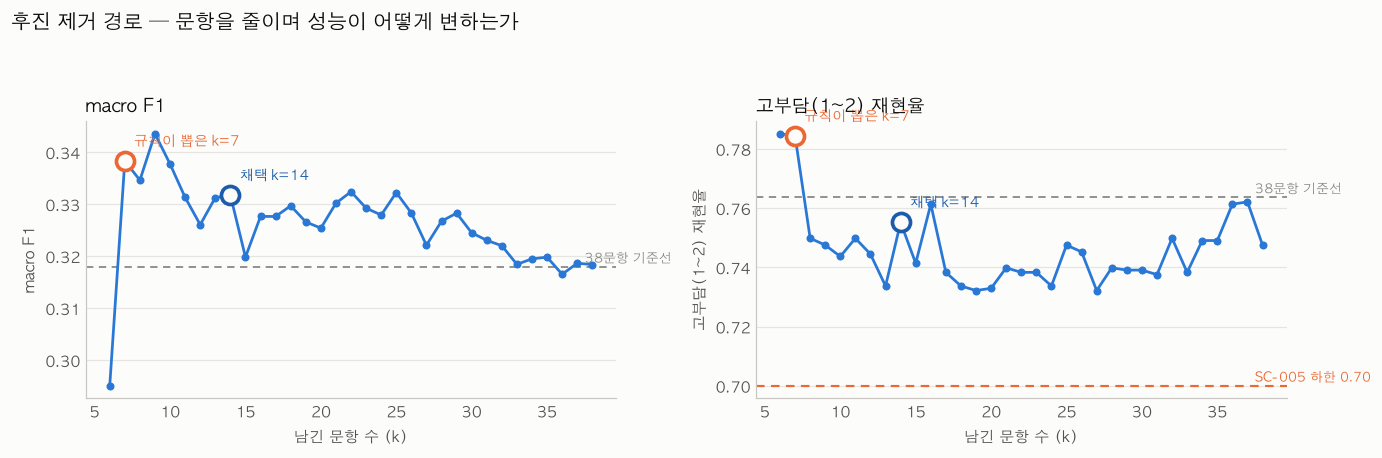

정지 조건에 걸린 지점 : k=6  (F1 손실 +0.0229 > 허용 0.019999999999999997)
규칙이 뽑는 최소 문항 수 : k=7
실제 채택 : k=14  — 성능 최적점이 아니라 제품 판단 (selection_v1.json 의 k_source)

  38문항 : F1 0.3180 · 재현율 0.7636
  14문항 : F1 0.3317 · 재현율 0.7552
  → 문항을 24개 줄였는데 macro F1 은 오히려 올랐다. 변수를 덜어내며 과적합이 함께 빠진 결과다.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2), sharex=True)
for ax, col, lab, base_v, floor in [
        (axes[0], 'macro_f1', 'macro F1', BASE['macro_f1'], None),
        (axes[1], 'recall', '고부담(1~2) 재현율', BASE['high_burden_recall'], T.MIN_REC_ABS)]:
    style(ax)
    ax.plot(P.index, P[col], color=CAT1, lw=1.8, zorder=3)
    ax.scatter(P.index, P[col], s=18, color=CAT1, zorder=4)
    ax.axhline(base_v, color=CAT3, lw=1.2, ls=(0,(4,3)), zorder=2)
    ax.annotate('38문항 기준선', (37.5, base_v), fontsize=8.5, color=CAT3, va='bottom')
    if floor:
        ax.axhline(floor, color=CAT2, lw=1.4, ls=(0,(4,3)), zorder=2)
        ax.annotate('SC-005 하한 0.70', (37.5, floor), fontsize=8.5, color=CAT2, va='bottom')
    for k, c, t in [(14, '#1c5cab', '채택 k=14'), (7, CAT2, '규칙이 뽑은 k=7')]:
        if k in P.index:
            ax.scatter([k], [P.loc[k,col]], s=140, facecolor=SURFACE, edgecolor=c, lw=2.4, zorder=5)
            ax.annotate(t, (k, P.loc[k,col]), textcoords='offset points', xytext=(6,10),
                        fontsize=9, color=c, fontweight='bold')
    ax.set_xlabel('남긴 문항 수 (k)'); ax.set_ylabel(lab); ax.set_title(lab, loc='left')
    ax.invert_xaxis()
fig.suptitle('후진 제거 경로 — 문항을 줄이며 성능이 어떻게 변하는가', x=0.005, ha='left',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0,0,1,0.92]); plt.show()

fail = P[~P['passes']]
print(f'정지 조건에 걸린 지점 : k={fail.index[0]}  (F1 손실 {fail.iloc[0]["f1_loss"]:+.4f} > 허용 {T.MAX_F1_LOSS-T.F1_MARGIN})')
print(f'규칙이 뽑는 최소 문항 수 : k={P[P["passes"]].index.min()}')
print(f'실제 채택 : k=14  — 성능 최적점이 아니라 제품 판단 (selection_v1.json 의 k_source)')
print()
print(f'  38문항 : F1 {BASE["macro_f1"]:.4f} · 재현율 {BASE["high_burden_recall"]:.4f}')
print(f'  14문항 : F1 {P.loc[14,"macro_f1"]:.4f} · 재현율 {P.loc[14,"recall"]:.4f}')
print('  → 문항을 24개 줄였는데 macro F1 은 오히려 올랐다. 변수를 덜어내며 과적합이 함께 빠진 결과다.')

## 6. 채택된 14문항과 계수

원-핫 인코딩 때문에 변수 하나가 여러 열을 차지한다. **변수별 중요도는 그 변수가 차지하는
열들의 계수 절댓값 평균**으로 본다(후진 제거에서 탈락 순서를 정할 때 쓴 것과 같은 기준).

,feature,원문항,문항,원핫 열수,평균 |계수|
0,household_head_type,I4,가구의 생계를 주로 책임지는 분은 누구인가요?,8,0.3240
1,understands_work_meaning,F1,"당사자는 ""일을 한다""는 것의 의미를 어느 정도 이해하고 있나요?",4,0.3237
2,help_needed_hours,G6,돌보고 계신 당사자에게 하루 중 어느 정도의 도움이 필요한가요?,5,0.3120
3,family_support_for_employment,F5,당사자의 취업에 대해 가족들이 어느 정도 지지하고 있나요?,6,0.3076
4,relation_to_person,A1,응답하시는 분은 당사자와 어떤 관계인가요?,8,0.3020
5,daily_routine_satisfaction,G8,당사자는 요즘 하루하루의 일과를 어떻게 느끼고 있나요?,6,0.2865
6,caregiver_age,I9_2,주로 돌보시는 분(주 보호자)의 만 나이는 어떻게 되나요?,78,0.2759
7,last_job_quit_reason,E4,(일을 그만둔 적이 있다면) 마지막 일자리를 그만둔 가장 큰 이유는 무엇인가,16,0.2734
8,final_school,B1,당사자가 마지막으로 다닌 학교는 어디인가요?,7,0.2644
9,overall_health,G1,당사자의 전반적인 건강 상태는 어떤가요?,5,0.2447


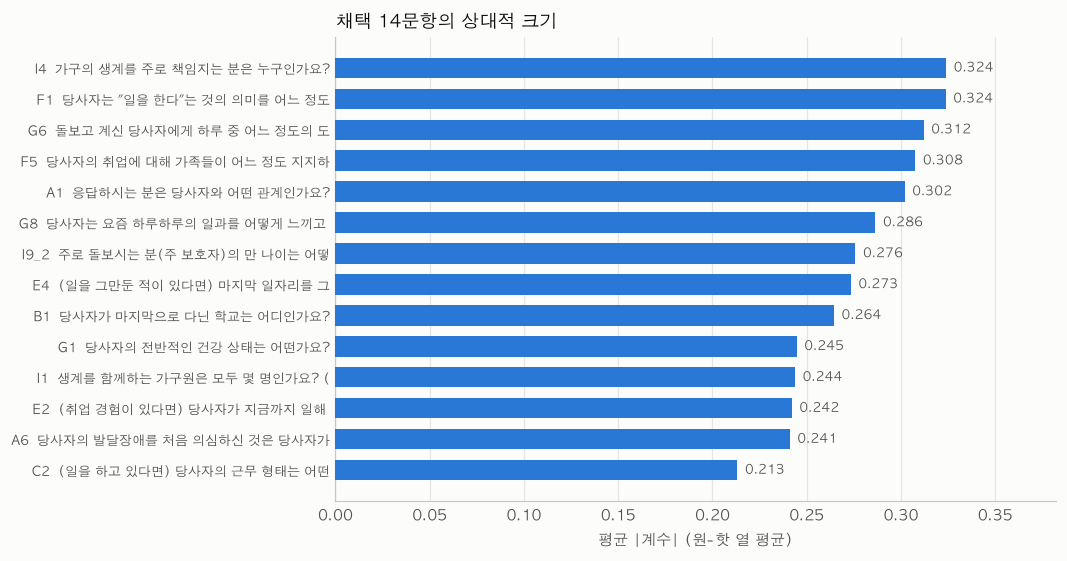

원-핫 총 열수 : 224  (클래스 5개)
주의 — 연속형 2개가 열의 대부분을 차지한다:
   caregiver_age                 78열
   age_disability_suspected      60열
   합계 138열 / 전체 224열 = 62%
   나이를 범주로 취급하면 57세와 58세가 무관한 별개 범주가 되어 순서 정보가 버려진다.


In [7]:
model = json.loads((ROOT/'models'/'model_v1.json').read_text(encoding='utf-8'))
qs    = json.loads((ROOT/'models'/'questions_v1.json').read_text(encoding='utf-8'))
sel14 = model['features']
coef  = np.array(model['coef'])
spans = model['spans']

imp = pd.DataFrame({
    'feature': sel14,
    '원문항': [q['originalItem'] for q in qs['questions']],
    '문항': [q['text'][:42] for q in qs['questions']],
    '원핫 열수': [s[1] for s in spans],
    '평균 |계수|': [float(np.abs(coef[:, s[0]:s[0]+s[1]]).mean()) for s in spans],
}).sort_values('평균 |계수|', ascending=False)
display(imp.round(4).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9.8, 5.2))
style(ax, grid='x')
dd = imp.sort_values('평균 |계수|')
ax.barh(np.arange(len(dd)), dd['평균 |계수|'], height=0.66, color=CAT1, zorder=3)
for i, v in enumerate(dd['평균 |계수|']):
    ax.annotate(f'{v:.3f}', (v+0.004, i), va='center', fontsize=8.5, color=INK2)
ax.set_yticks(np.arange(len(dd)))
ax.set_yticklabels([f"{r['원문항']}  {r['문항'][:26]}" for _, r in dd.iterrows()], fontsize=8.6)
ax.set_xlim(0, dd['평균 |계수|'].max()*1.18)
ax.set_xlabel('평균 |계수| (원-핫 열 평균)')
ax.set_title('채택 14문항의 상대적 크기', loc='left')
fig.tight_layout(); plt.show()

print(f'원-핫 총 열수 : {coef.shape[1]}  (클래스 {coef.shape[0]}개)')
big = imp.nlargest(2, '원핫 열수')
print(f'주의 — 연속형 2개가 열의 대부분을 차지한다:')
for _, r in big.iterrows():
    print(f"   {r['feature']:28s} {r['원핫 열수']:3d}열")
print(f"   합계 {big['원핫 열수'].sum()}열 / 전체 {coef.shape[1]}열 = {big['원핫 열수'].sum()/coef.shape[1]*100:.0f}%")
print('   나이를 범주로 취급하면 57세와 58세가 무관한 별개 범주가 되어 순서 정보가 버려진다.')

## 7. "판단할 수 없음" — 판정 불가 (FR-009a)

다섯 구간과 별개로 **판정 불가**라는 결과를 둔다. 두 신호를 **OR**로 묶는다.

| 신호 | 조건 | 뜻 |
|---|---|---|
| 확신도 | `max(확률) < τ_conf` | 어느 구간도 자신 있게 고르지 못함 |
| 희소성 | `rarity < τ_dens` | 학습 데이터에서 드문 응답 조합 |

임계값은 사람이 정하지 않았다. **판정 불가 집단의 오분류율이 판정된 집단보다 높으면서 발생률이
10% 이하**인 조합 중 발생률이 가장 낮은 지점을 격자 탐색으로 찾았다(SC-016).

τ_conf = 0.3349   τ_dens = -2.5354
판정 불가 : 72건 / 2398건 = 3.0%
  오분류율  판정불가 0.653  vs  판정됨 0.571

발동 원인 분해:
  확신도만       48건  ( 2.0%)
  희소성만       24건  ( 1.0%)
  둘 다         0건  ( 0.0%)


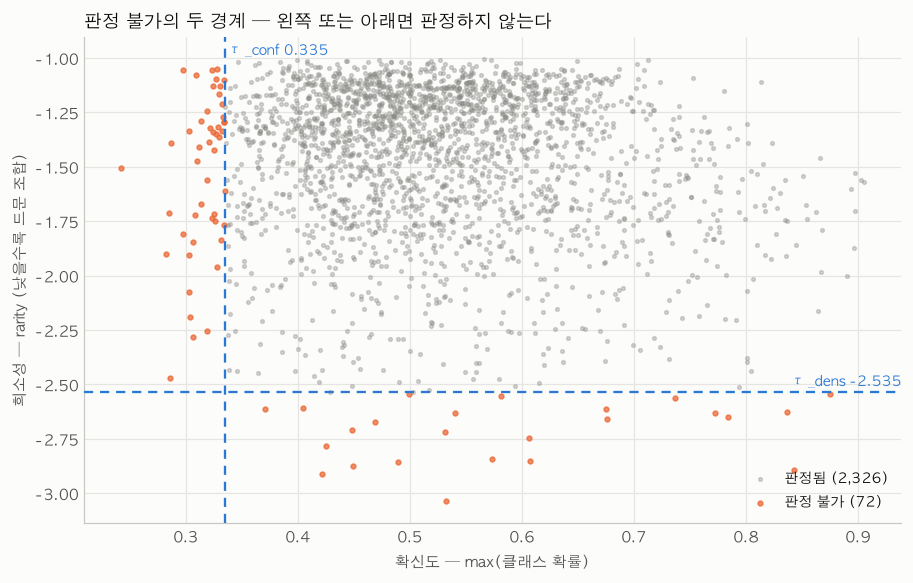

In [8]:
unc = json.loads((ROOT/'models'/'uncertainty_v1.json').read_text(encoding='utf-8'))
tau_conf, tau_dens = unc['tau_conf'], unc['tau_dens']

cols = [idx[f] for f in sel14]
Xs = X[:, cols]
r14 = T.cv_scores(Xs, y, folds, sel14, family=best)
proba = r14['oof_proba']
conf = proba.max(axis=1)
table = T.build_freq_table(Xs, sel14)
rar = np.array([T.rarity(Xs[i], sel14, table) for i in range(len(Xs))])
und = (conf < tau_conf) | (rar < tau_dens)
pred = T.decide(proba, model['decision_weights'])

print(f'τ_conf = {tau_conf:.4f}   τ_dens = {tau_dens:.4f}')
print(f'판정 불가 : {und.sum()}건 / {len(und)}건 = {und.mean()*100:.1f}%')
print(f'  오분류율  판정불가 {(pred[und]!=y[und]).mean():.3f}  vs  판정됨 {(pred[~und]!=y[~und]).mean():.3f}')
print()
print('발동 원인 분해:')
c_only = (conf < tau_conf) & (rar >= tau_dens)
d_only = (conf >= tau_conf) & (rar < tau_dens)
both   = (conf < tau_conf) & (rar < tau_dens)
for lab, m in [('확신도만', c_only), ('희소성만', d_only), ('둘 다', both)]:
    print(f'  {lab:8s} {m.sum():4d}건  ({m.sum()/len(und)*100:4.1f}%)')

fig, ax = plt.subplots(figsize=(8.4, 5.4))
style(ax, grid=None)
ax.grid(color=GRID, lw=0.8)
ax.scatter(conf[~und], rar[~und], s=6, color=CAT3, alpha=0.35, zorder=3, label=f'판정됨 ({(~und).sum():,})')
ax.scatter(conf[und], rar[und], s=10, color=CAT2, alpha=0.75, zorder=4, label=f'판정 불가 ({und.sum():,})')
ax.axvline(tau_conf, color=CAT1, lw=1.5, ls=(0,(4,3)), zorder=5)
ax.axhline(tau_dens, color=CAT1, lw=1.5, ls=(0,(4,3)), zorder=5)
ax.annotate(f'τ_conf {tau_conf:.3f}', (tau_conf, ax.get_ylim()[1]), textcoords='offset points',
            xytext=(4,-12), color=CAT1, fontsize=9)
ax.annotate(f'τ_dens {tau_dens:.3f}', (ax.get_xlim()[1], tau_dens), textcoords='offset points',
            xytext=(-70,4), color=CAT1, fontsize=9)
ax.set_xlabel('확신도 — max(클래스 확률)'); ax.set_ylabel('희소성 — rarity (낮을수록 드문 조합)')
ax.set_title('판정 불가의 두 경계 — 왼쪽 또는 아래면 판정하지 않는다', loc='left')
ax.legend(frameon=False, loc='lower right', fontsize=9)
fig.tight_layout(); plt.show()

---

## 정리

| 단계 | 확인한 것 | 결과 |
|---|---|---|
| 2 | 분할 무결성 | train 2,398 / test 602 · fold 1~5 · 배제 6변수 부재 |
| 3 | 층화 유지 | 최대 오차 0.16%p · 5단계 61건이 병목 |
| 4 | 계열 선택 | **로지스틱 채택** — 트리 계열이 소표본에서 과적합 |
| 5 | 문항 선별 | 38 → 14. 줄였는데 macro F1 은 오히려 상승 |
| 6 | 계수 구조 | 원-핫 224열 중 62%가 나이 2개 변수 (한계) |
| 7 | 판정 불가 | 3% 수준 · 오분류율이 판정된 집단보다 높음 (SC-016 충족) |

## 이 노트북이 하지 않은 것

- **test 602건을 쓰지 않았다.** 모든 수치는 train 2,398건의 교차검증 값이다.
  최종 평가는 `python3 ml/train.py evaluate` 로 **단 한 번만** 수행한다.
- **인과를 주장하지 않는다.** 계수가 크다고 그 문항이 부담의 원인이라는 뜻이 아니다.
  일부 변수는 부담의 **결과**에 가깝다.
- **문항 수 14를 데이터로 정당화하지 않는다.** 규칙이 뽑은 값은 7이며, 14는 제품 판단이다.